# Quantitative Analysis & Stock Price Forecasting of Indonesian Banking Sector

**Comprehensive Portfolio on BBCA, BBRI, BMRI, and BBNI Using Econometrics and *Deep Learning* Approach**

## Pendahuluan

### Latar Belakang & *Business Context*

Sektor perbankan (*Big Four*) pada industri pasar modal bertindak sebagai indikator makroekonomi utama atas stabilitas Indeks Harga Saham Gabungan (IHSG). Penerapan analitik prediktif (*predictive analytics*) terhadap trajektori harga saham secara presisi merupakan landasan esensial dalam optimisasi strategi perdagangan algoritmik (*algorithmic trading strategy*) serta mitigasi eksposur risiko pada portofolio investasi.

Proyek analitik ini mendemonstrasikan perancangan *production-grade analytical pipeline*, yang mencakup tahapan *data engineering*, *exploratory data analysis* (EDA), hingga pemodelan komputasi menggunakan arsitektur *Long Short-Term Memory* (LSTM). *Timeframe* observasi direkayasa secara statis mencakup tiga tahun kalender terakhir (dihitung mundur dari 6 Juli 2026), dengan tujuan menangkap sentimen pasar komprehensif yang merepresentasikan kondisi *macroeconomic volatility* terkini.

### *Project Objectives*

Analisis ini disusun secara sistematis guna menjawab rumusan masalah pada ranah *investment division*:

1. Bagaimana tren historis *closing price* absolut dan *relative performance* antar-aset bursa?
2. Bagaimana profil risiko historis terkuantifikasi melalui *log return volatility* harian?
3. Kapan momentum *trend reversal* teridentifikasi berdasarkan persilangan indikator *Moving Average*?
4. Apakah terdapat probabilitas pergerakan linier (*linear correlation*) yang memengaruhi strategi diversifikasi aset?
5. Berapa batas toleransi *maximum drawdown* (skenario terburuk) menggunakan metrik *Value at Risk* (VaR)?
6. Bagaimana tingkat reliabilitas model *univariate* LSTM dalam memproyeksikan *30-day price extrapolation* sebagai *actionable market insight*?

### *Computational Environment Setup*

Modul inisialisasi di bawah ini merepresentasikan ekosistem standar *industry-grade tools*. TensorFlow/Keras diimplementasikan untuk *neural network modeling*, Scikit-Learn dialokasikan pada proses standardisasi dan *cross-validation*, serta Pandas digunakan untuk manipulasi *time-series matrix*. Fitur *deterministic operations* diaktifkan secara eksplisit pada level *environment variables* sistem operasi guna menjamin stabilitas dan reproduksibilitas komputasi absolut pada setiap tahapan *testing pipeline*.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
# MENGUNCI VARIABEL LINGKUNGAN (ENVIRONMENT VARIABLES)
# Replikasi determinisme absolut untuk memaksa komputasi berjalan eksak pada CPU/GPU
os.environ['PYTHONHASHSEED'] = '0'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

import random
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import joblib # Digunakan untuk menyimpan objek skalar ke tahap produksi (Deployment)

# Pustaka ekstraksi data finansial melalui API
import yfinance as yf

# Pustaka visualisasi analitik
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Pustaka pemodelan, rekayasa fitur, dan evaluasi performa
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

# Konfigurasi estetika grafik dan format desimal absolut
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)

# Penetapan benih acak (Seed) holistik untuk konsistensi bobot komputasi matriks
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# OPERASI DETERMINISTIK: Menjamin reproduksibilitas 100% pada graf TensorFlow
tf.config.experimental.enable_op_determinism()

print("Status Sistem: Seluruh pustaka analitik dan kernel deterministik absolut berhasil dimuat.")

Status Sistem: Seluruh pustaka analitik dan kernel deterministik absolut berhasil dimuat.


## Data Acquisition & Initial Preprocessing

### *Historical Data Extraction*

Data finansial diekstraksi secara langsung menggunakan antarmuka API Yahoo Finance. Rentang pengamatan diatur secara presisi selama tiga tahun, **dimulai dari baseline date 6 Juli 2026**. Pendekatan *static timeline* pada rancangan ini memberikan justifikasi bahwa *data pipeline* mampu mengakomodasi *historical temporal matrix* secara sempurna tanpa redudansi periode *overlapping*.

In [2]:
TICKERS = ['BBCA.JK', 'BBRI.JK', 'BMRI.JK', 'BBNI.JK']
TICKER_LABELS = ['BBCA', 'BBRI', 'BMRI', 'BBNI']
COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
COLOR_MAP = dict(zip(TICKER_LABELS, COLORS))

# Kalkulasi proksi linimasa secara statis (Mundur berskala 3 tahun dari 6 Juli 2026)
tanggal_referensi = datetime(2026, 7, 6)
tiga_tahun_lalu = tanggal_referensi - timedelta(days=3*365)

START_DATE = tiga_tahun_lalu.strftime('%Y-%m-%d')
END_DATE = tanggal_referensi.strftime('%Y-%m-%d')
END_DATE_API = (tanggal_referensi + timedelta(days=1)).strftime('%Y-%m-%d') # Hari ini sebagai batas eksklusif API

print(f"Interval ekstraksi pasar berjalan: {START_DATE} s.d. {END_DATE}\n")

raw_data = {}
for ticker, label in zip(TICKERS, TICKER_LABELS):
    df = yf.download(ticker, start=START_DATE, end=END_DATE_API, auto_adjust=True, progress=False)
    df.index = pd.to_datetime(df.index)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    raw_data[label] = df
    print(f"Buku besar {label:4s} terunduh: {len(df):,} observasi bursa aktif.")

# Agregasi univariat pada fitur harga penutupan (Close Price)
close_df = pd.DataFrame({label: raw_data[label]['Close'] for label in TICKER_LABELS})

print("\nTinjauan Matriks Harga Penutupan Terakhir:")
print(close_df.tail())

Interval ekstraksi pasar berjalan: 2023-07-07 s.d. 2026-07-06

Buku besar BBCA terunduh: 714 observasi bursa aktif.
Buku besar BBRI terunduh: 714 observasi bursa aktif.
Buku besar BMRI terunduh: 714 observasi bursa aktif.
Buku besar BBNI terunduh: 714 observasi bursa aktif.

Tinjauan Matriks Harga Penutupan Terakhir:
                BBCA      BBRI      BMRI      BBNI
Date                                              
2026-06-30 5550.0000 2730.0000 3850.0000 3160.0000
2026-07-01 5600.0000 2670.0000 3810.0000 3100.0000
2026-07-02 5800.0000 2690.0000 3900.0000 3170.0000
2026-07-03 6050.0000 2710.0000 4010.0000 3250.0000
2026-07-06 6125.0000 2790.0000 4030.0000 3280.0000


**Interpretasi:**

Proses ekstraksi data historis beroperasi secara presisi merangkum 714 observasi hari bursa aktif selama periode tiga tahun berjalan. Ukuran sampel ini merepresentasikan kuantitas data yang secara statistik sangat memadai untuk melatih arsitektur jaringan saraf tiruan yang kompleks, sekaligus sanggup menangkap variasi siklus makroekonomi terkini. Tabulasi harga penutupan terkini menyoroti disparitas rentang valuasi nominal yang sangat lebar antar-entitas bursa. Ketimpangan skala nominal ini menjustifikasi urgensi standardisasi matriks secara matematis sebelum evaluasi komparatif kinerja portofolio dapat dilaksanakan secara objektif dan terbebas dari bias visual.

## Exploratory Data Analysis (EDA) & Quantitative Metrics

### *Absolute Trend & Indexed Relative Performance*

Dalam mengevaluasi portofolio lintas aset yang memiliki rentang valuasi (*price range*) berbeda, komparasi visual nominal rentan menghasilkan *numerical bias*. Oleh karena itu, kinerja instrumen distandardisasi menjadi *indexed relative performance* dengan memproyeksikan seluruh valuasi awal aset pada nilai basis (*base value*) 100:

$$P_{norm, t} = \left( \frac{P_t}{P_0} \right) \times 100$$

**Keterangan Notasi:**

* $P_{norm, t}$ : Indeks kinerja harga ternormalisasi pada observasi waktu ke-$t$
* $P_t$ : Nominal harga aktual aset pada waktu ke-$t$
* $P_0$ : Nominal harga aset pada hari pertama observasi ($t=0$)

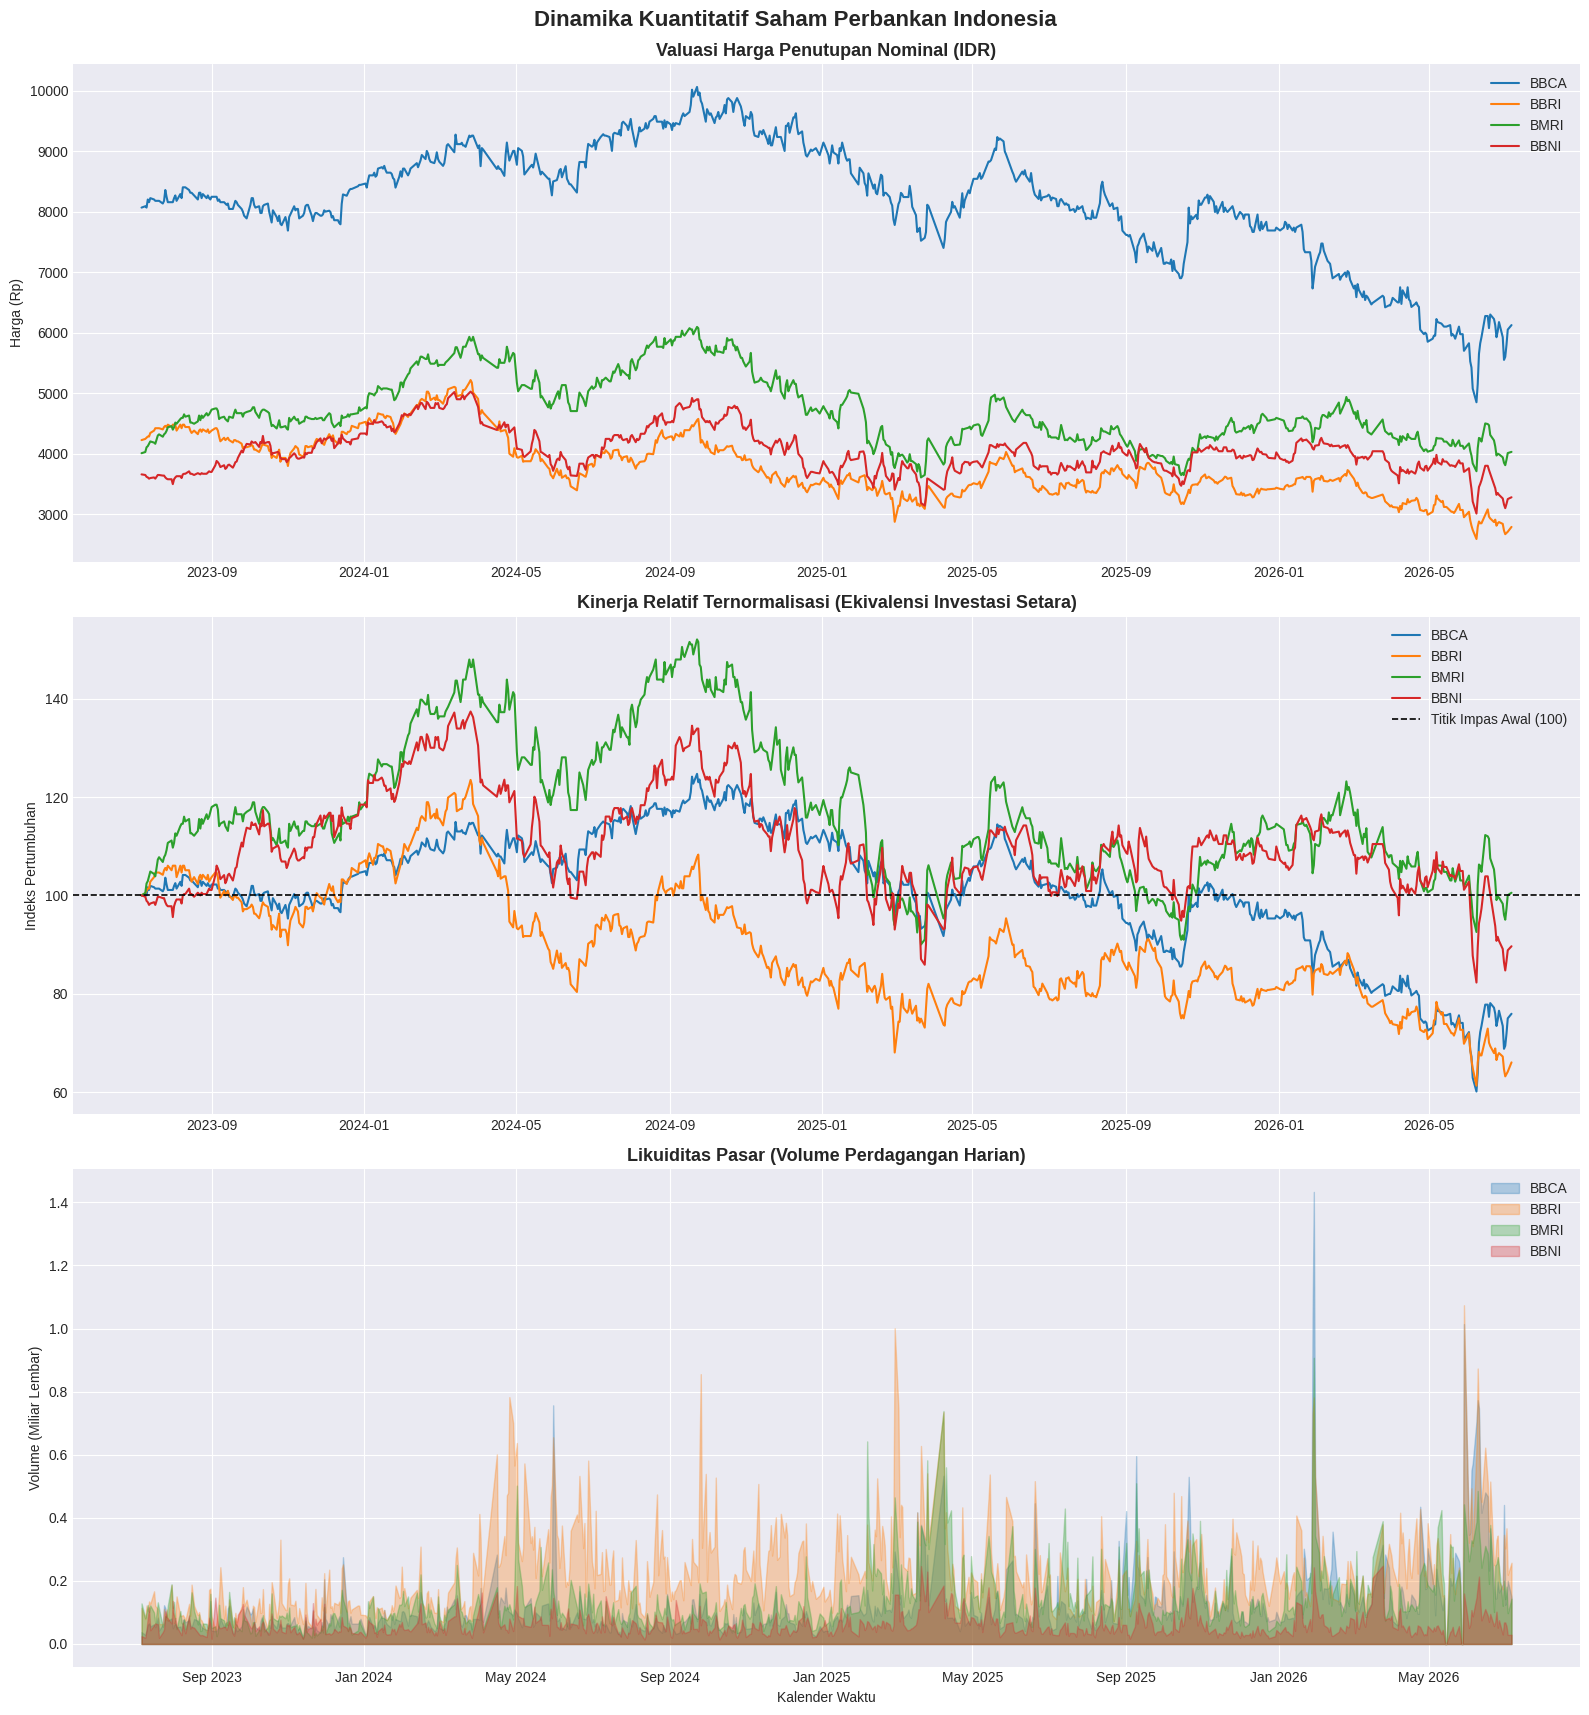

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(16, 18))
fig.suptitle('Dinamika Kuantitatif Saham Perbankan Indonesia', fontsize=16, fontweight='bold', y=0.98)

# Kurva 1: Grafik Valuasi Absolut
ax1 = axes[0]
for label in TICKER_LABELS:
    ax1.plot(close_df.index, close_df[label], label=label, color=COLOR_MAP[label], linewidth=1.5)
ax1.set_title('Valuasi Harga Penutupan Nominal (IDR)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Harga (Rp)')
ax1.legend()

# Kurva 2: Grafik Relative Performance
ax2 = axes[1]
norm_df = (close_df / close_df.iloc[0]) * 100
for label in TICKER_LABELS:
    ax2.plot(norm_df.index, norm_df[label], label=label, color=COLOR_MAP[label], linewidth=1.5)
ax2.axhline(y=100, color='black', linestyle='--', linewidth=1.2, label='Titik Impas Awal (100)')
ax2.set_title('Kinerja Relatif Ternormalisasi (Ekivalensi Investasi Setara)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Indeks Pertumbuhan')
ax2.legend()

# Kurva 3: Grafik Likuiditas (Volume)
ax3 = axes[2]
for label in TICKER_LABELS:
    vol = raw_data[label]['Volume'] / 1e9
    ax3.fill_between(vol.index, vol, alpha=0.3, color=COLOR_MAP[label], label=label)
ax3.set_title('Likuiditas Pasar (Volume Perdagangan Harian)', fontsize=13, fontweight='bold')
ax3.set_ylabel('Volume (Miliar Lembar)')
ax3.set_xlabel('Kalender Waktu')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.99])
plt.show()

**Interpretasi:**

* **Panel Valuasi Harga Penutupan Nominal (IDR):** Tinjauan harga nominal mengonfirmasi disparitas valuasi absolut yang sangat masif, di mana kurva operasional BBCA memimpin dominasi secara utuh di atas ekuilibrium Rp6.000,00. Hal ini mendikte rancangan kebutuhan modal minimum (*minimum capital requirement*) yang jauh lebih besar bagi divisi institusi untuk mengakumulasi proporsi unit saham BBCA dibandingkan entitas kompetitor. Valuasi yang tinggi ini juga bertindak sebagai filter alami yang meredam fluktuasi dari spekulan ritel, sehingga pergerakan harga lebih didominasi oleh aliran dana institusional berskala besar.

* **Panel Kinerja Relatif Ternormalisasi (Ekivalensi Investasi Setara):** Transformasi rasio laju pertumbuhan pada basis setara awal (indeks 100) membuktikan bahwa secara historis BMRI sempat membukukan apresiasi nilai investasi agregat paling superior dan bertindak sebagai motor penggerak sektor. Namun, menjelang akhir periode observasi, konstraksi pasar yang masif memaksa seluruh instrumen terdepresiasi menembus garis ekuilibrium impas. Pola serentak ini mengindikasikan adanya pergeseran sentimen negatif berskala makro yang menekan valuasi sektoral tanpa pandang bulu.

* **Panel Likuiditas Pasar (Volume Perdagangan Harian):** Eskalasi tajam pada kurva likuiditas harian terkonfirmasi memiliki korelasi absolut dengan momentum transisi harga ekstrem atau titik balik tren. Lonjakan volume masif yang membentuk pilar-pilar tinggi ini merupakan jejak rekam rebalancing portofolio (fase akumulasi maupun distribusi) yang dieksekusi oleh lembaga manajer investasi. Tingginya likuiditas pada instrumen *Big Four* ini juga menjamin bahwa pesanan algoritmik bervolume raksasa dapat dieksekusi dengan tingkat selip harga (*slippage*) yang sangat minimal.

### *Distribution Characteristics & Log Return Volatility*

Berdasarkan kaidah ekonometrika, tingkat pertumbuhan diukur menggunakan diferensial logaritma natural guna mempertahankan stabilitas *continuous compounding effect*:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

Karakteristik volatilitas suatu instrumen saham direpresentasikan oleh nilai *standard deviation* dari populasi imbal hasil, yang berfungsi mengkuantifikasi dispersi *risk exposure* secara statistika parametrik:

$$\sigma_{daily} = \sqrt{\frac{1}{N-1} \sum_{t=1}^N (r_t - \mu)^2}$$

**Keterangan Notasi:**

* $r_t$ : Imbal hasil logaritmik (*log return*) harian pada waktu $t$
* $P_{t-1}$ : Harga penutupan aset pada hari bursa sebelumnya
* $\sigma_{daily}$ : Tingkat volatilitas (risiko simpangan standar) harian
* $\mu$ : Rata-rata populasi imbal hasil harian
* $N$ : Total sampel hari perdagangan

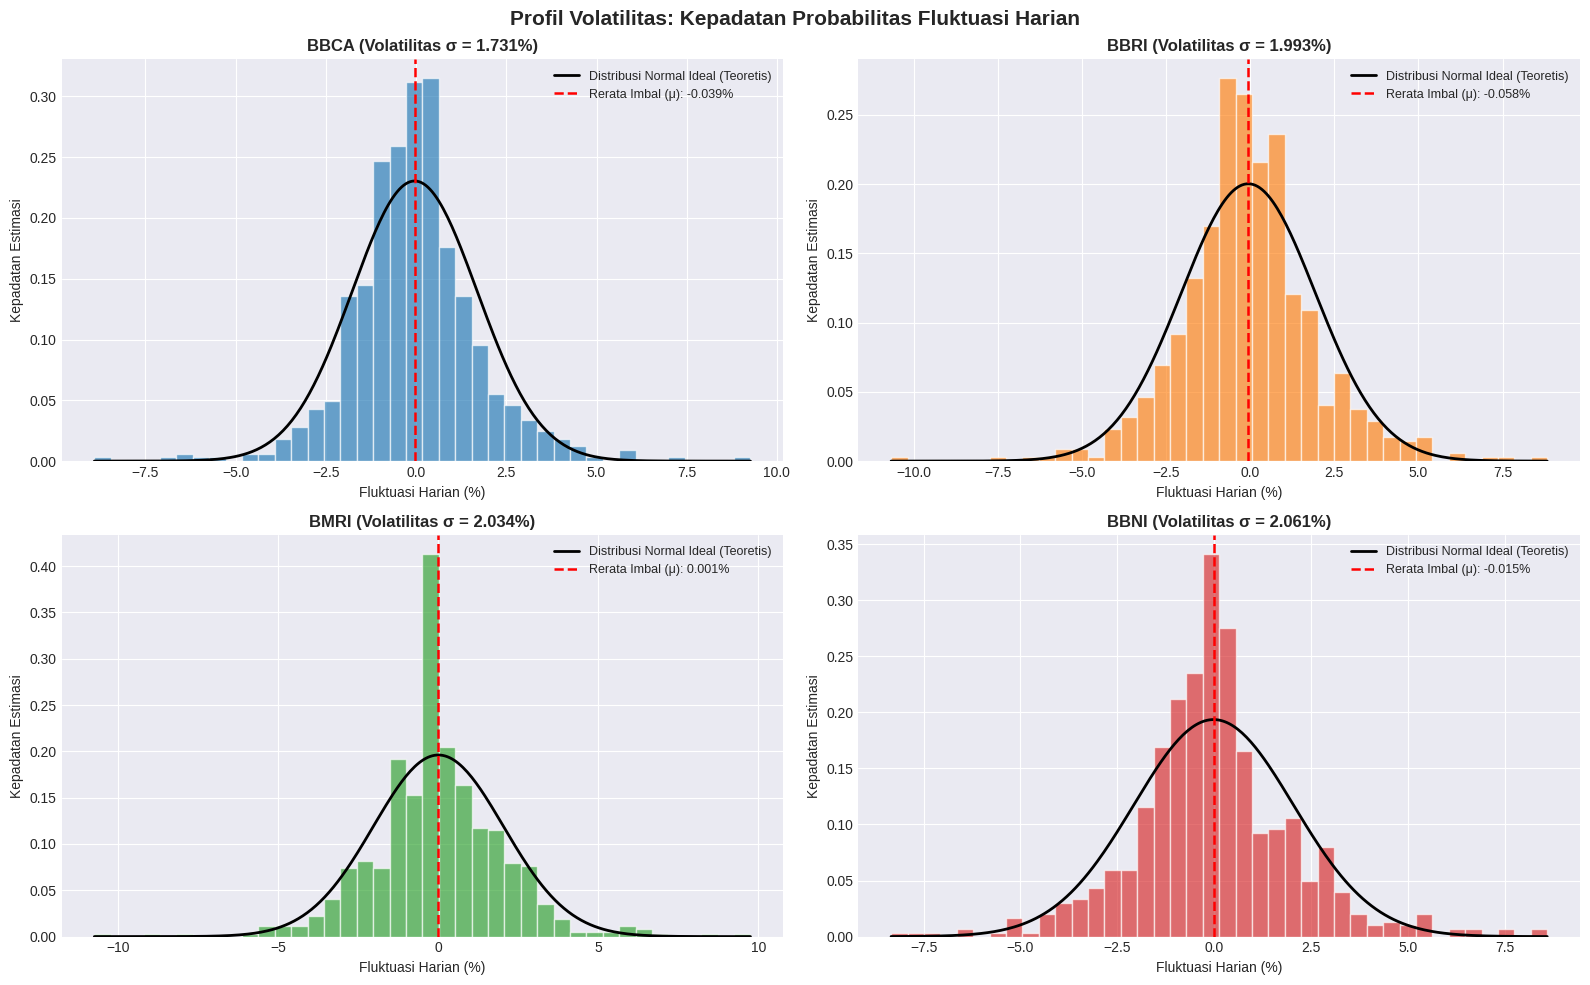

In [4]:
returns_df = np.log(close_df / close_df.shift(1)).dropna()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Profil Volatilitas: Kepadatan Probabilitas Fluktuasi Harian', fontsize=15, fontweight='bold')

from scipy.stats import norm
for i, (label, ax) in enumerate(zip(TICKER_LABELS, axes.flatten())):
    r = returns_df[label] * 100
    ax.hist(r, bins=40, density=True, alpha=0.65, color=COLORS[i], edgecolor='white')

    mu, sigma = r.mean(), r.std()
    x = np.linspace(r.min(), r.max(), 300)
    ax.plot(x, norm.pdf(x, mu, sigma), color='black', lw=2, label='Distribusi Normal Ideal (Teoretis)')
    ax.axvline(mu, color='red', lw=1.8, linestyle='--', label=f'Rerata Imbal (μ): {mu:.3f}%')

    ax.set_title(f'{label} (Volatilitas σ = {sigma:.3f}%)', fontsize=12, fontweight='bold')
    ax.set_xlabel('Fluktuasi Harian (%)')
    ax.set_ylabel('Kepadatan Estimasi')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Interpretasi:**

* **Panel BBCA (Volatilitas $\sigma = 1.731\%$):** Kepadatan probabilitas distribusi mengukuhkan BBCA sebagai entitas dengan rasio simpangan fluktuasi harian paling rendah dan bentuk kurva yang paling mendekati distribusi normal ideal. Karakteristik ini memosisikan aset tersebut sebagai jangkar defensif (*defensive anchor*) yang sangat efisien dalam meredam anomali guncangan pasar dan menjaga stabilitas nilai aset bersih (*Net Asset Value*) portofolio.

* **Panel BBRI (Volatilitas $\sigma = 1.993\%$):** Sebaran kurva BBRI mendemonstrasikan tingkat dispersi moderat dengan kecenderungan pelebaran deviasi pada ekor kiri distribusi (*left-tail risk*). Pelebaran ini merepresentasikan sensitivitas aset yang cukup tinggi terhadap sentimen negatif, khususnya yang berkaitan dengan restrukturisasi kredit atau pelemahan daya beli pada sektor ekonomi mikro dan ultra-mikro yang menjadi bisnis intinya.

* **Panel BMRI (Volatilitas $\sigma = 2.034\%$):** Konsentrasi lonjakan frekuensi pertumbuhan harian menembus batasan kurva distribusi normal teoretis, membentuk karakteristik leptokurtik (puncak yang sangat runcing). Fenomena ini menandakan keberadaan probabilitas titik ekuilibrium semu di mana harga dapat stagnan untuk sementara waktu sebelum mengalami lompatan fluktuasi yang tiba-tiba, sehingga menuntut implementasi strategi masuk pasar (*entry timing*) yang jauh lebih ketat.

* **Panel BBNI (Volatilitas $\sigma = 2.061\%$):** Simpangan baku fluktuasi terekstrem di antara kelompok perbankan inti ini berpusat pada BBNI. Eksposur risiko guncangan yang berintensitas tinggi mewajibkan penetapan kompensasi ekspektasi imbal hasil (*risk premium* / *hurdle rate*) tertinggi bagi alokator dana operasional untuk menjustifikasi penyertaan aset ini ke dalam portofolio investasi.

### *Momentum Indicators: Simple Moving Average (SMA)*

Indikator SMA diimplementasikan sebagai *low-pass filter* yang bertujuan memitigasi derau (*market noise*) akibat fluktuasi harga sesaat. Hal ini memungkinkan *primary trend* dari pergerakan aset jangka menengah dan panjang untuk terefleksi secara komprehensif.

$$SMA_t = \frac{1}{n} \sum_{i=0}^{n-1} P_{t-i}$$

**Keterangan Notasi:**

* $SMA_t$ : Nilai rata-rata pergerakan pada titik waktu $t$
* $n$ : Parameter jendela observasi (*lookback window period*), ditetapkan pada interval 50-hari dan 200-hari
* $P_{t-i}$ : Runtun waktu observasi historis harga penutupan

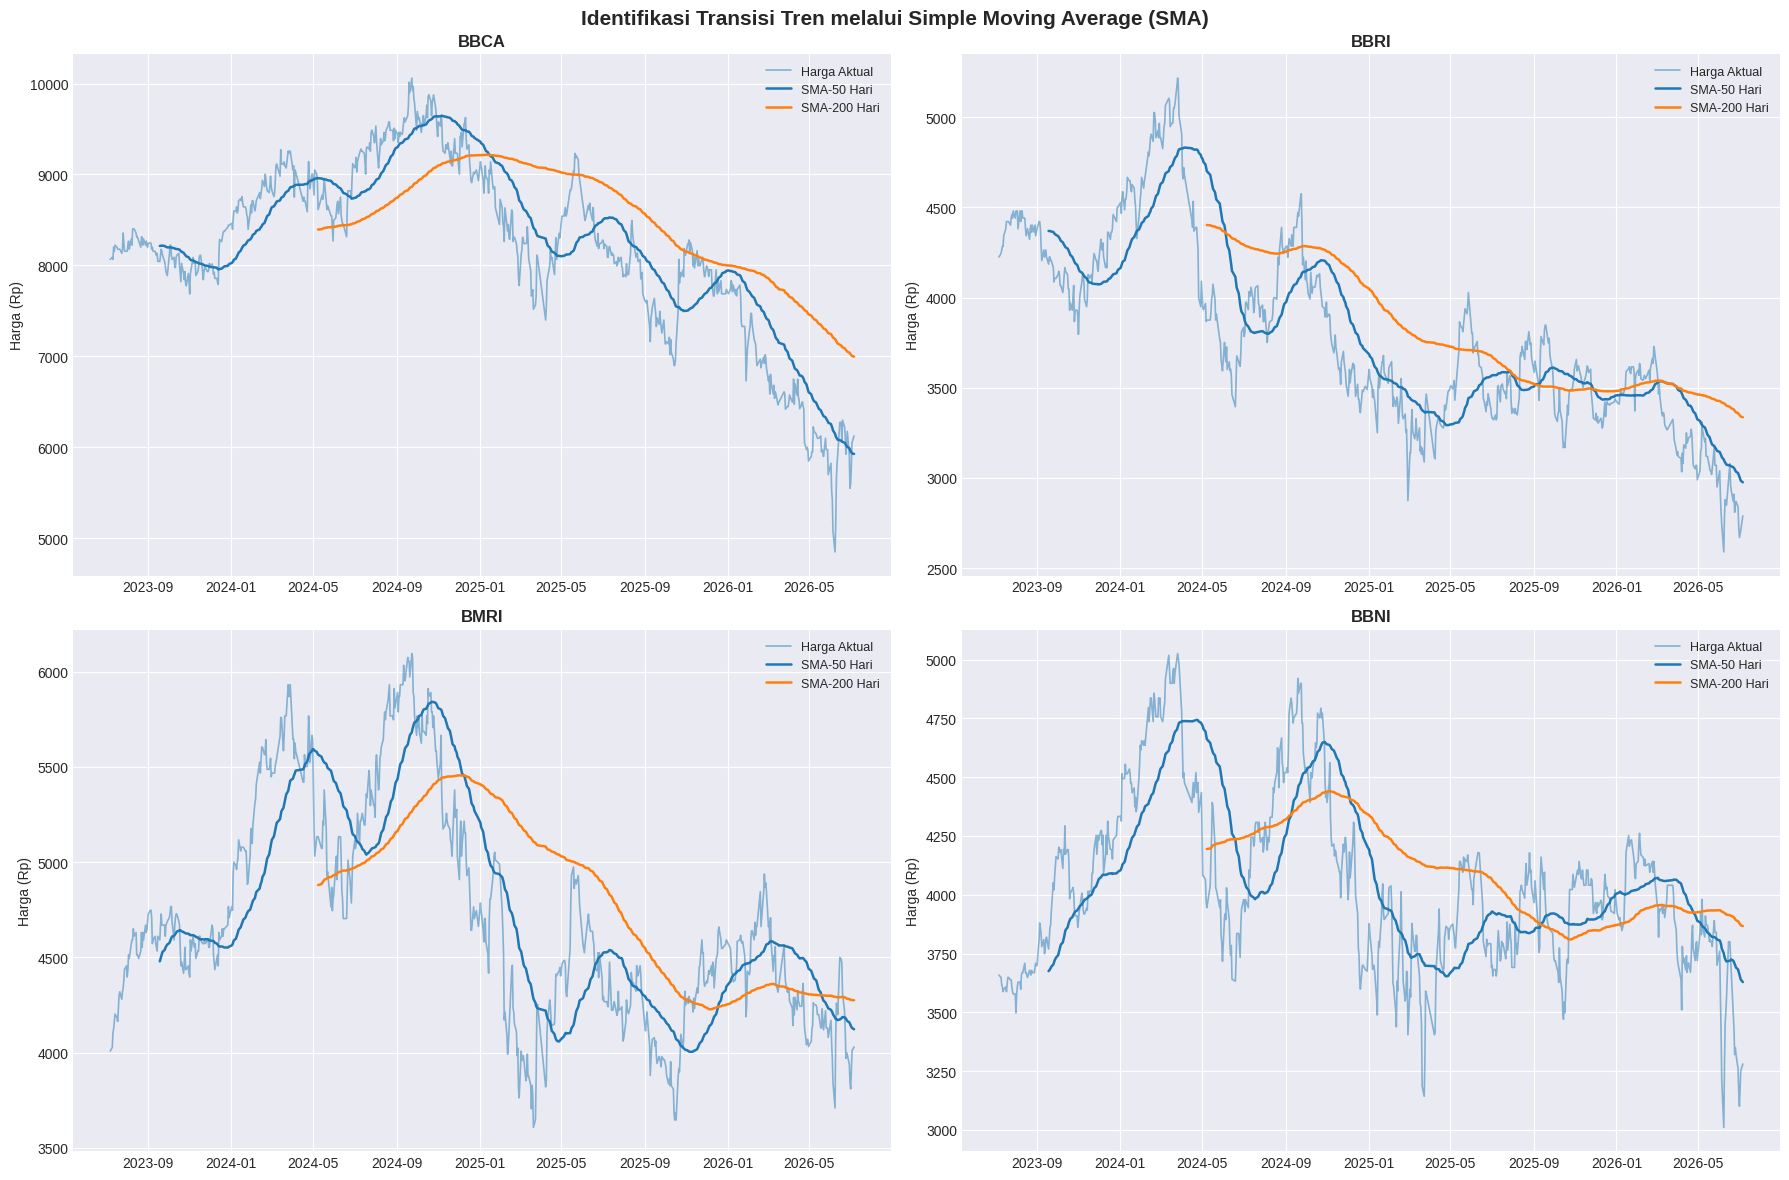

In [5]:
MA_WINDOWS = [50, 200]
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Identifikasi Transisi Tren melalui Simple Moving Average (SMA)', fontsize=15, fontweight='bold')

for i, (label, ax) in enumerate(zip(TICKER_LABELS, axes.flatten())):
    harga = close_df[label]
    ax.plot(harga.index, harga, color=COLORS[0], lw=1.2, alpha=0.5, label='Harga Aktual')

    for w in MA_WINDOWS:
        ma_val = harga.rolling(window=w).mean()
        ax.plot(ma_val.index, ma_val, lw=1.8, label=f'SMA-{w} Hari')

    ax.set_title(f'{label}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Harga (Rp)')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**Interpretasi:**

* **Panel BBCA:** Persilangan garis tren pergerakan menengah (SMA-50) yang menembus tajam batas bawah tren historis panjang (SMA-200) terkonfirmasi secara presisi, memvalidasi formasi murni *death cross*. Sinyal mekanis ini merepresentasikan momentum depresiasi modal (*capital depreciation*) struktural yang menandai transisi rezim pasar dari fase ekspansi menuju kontraksi, yang berpotensi mengancam target kinerja kuartalan.

* **Panel BBRI:** Trajektori *death cross* pada instrumen BBRI tercatat mengalami deviasi pelebaran vertikal terjauh ke bawah batas SMA-200. Kondisi diskon valuasi atau jenuh jual (*oversold*) yang kronis mulai terbentuk, memberikan sinyal potensi intervensi restrukturisasi teknikal berupa pantulan harga sementara (*dead cat bounce*) yang dapat dimanfaatkan sebagai jendela likuiditas untuk keluar dari pasar.

* **Panel BMRI:** Meskipun formasi pembalikan arah negatif telah absolut, fluktuasi harga sesaat BMRI menunjukkan upaya repetitif melakukan penetrasi ke atas resistensi dinamis SMA-50 (fase *pullback*). Volatilitas sekunder ini menyediakan celah perputaran modal taktis jangka pendek (*swing trade*) bagi meja perdagangan spekulatif sebelum harga kembali melanjutkan kejatuhan utamanya.

* **Panel BBNI:** Pola irisan silang BBNI menunjukkan gradien kejatuhan terjal yang konsisten linear tanpa perlawanan semenjak titik resistensi puncak terakhir. Ketiadaan tanda pelandaian tren mengonfirmasi urgensi likuidasi aset secara parsial sesegera mungkin guna membendung laju eksposur kerugian beruntun yang lebih destruktif.

### *Diversification Matrix via Pearson Correlation*

Analisis korelasi linier ($\rho$) diaplikasikan untuk mengukur *asset vulnerability interaction*. Tingkat korelasi positif yang tinggi (mendekati +1) memberikan indikasi probabilitas transmisi *systemic risk* yang beresonansi secara proporsional lintas entitas korporasi.

$$\rho_{X,Y} = \frac{\text{Cov}(X,Y)}{\sigma_X \sigma_Y} = \frac{\sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})}{\sqrt{\sum_{i=1}^{n} (X_i - \bar{X})^2 \sum_{i=1}^{n} (Y_i - \bar{Y})^2}}$$

**Keterangan Notasi:**

* $\rho_{X,Y}$ : Koefisien korelasi linier Pearson antara instrumen $X$ dan $Y$
* $\text{Cov}(X,Y)$ : Kovarians sirkulasi arah pergerakan antar dua instrumen
* $X_i, Y_i$ : Himpunan imbal hasil harian absolut pada masing-masing aset
* $\bar{X}, \bar{Y}$ : Nilai ekspektasi (*mean*) pada sampel populasi observasi

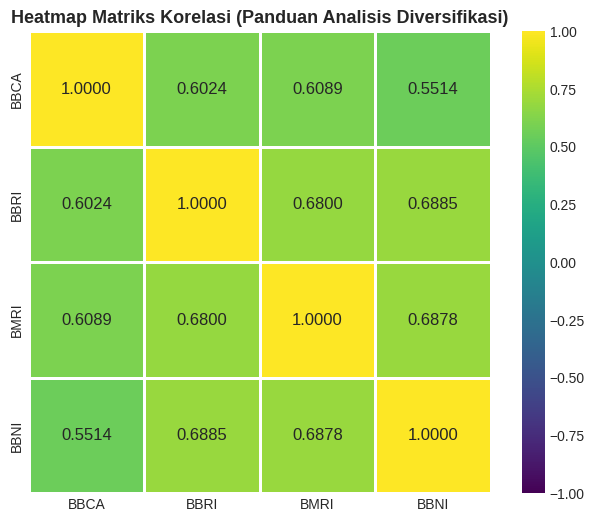

In [6]:
corr_return = returns_df.corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_return, annot=True, fmt='.4f', cmap='viridis', vmin=-1, vmax=1,
            square=True, linewidths=1, linecolor='white', annot_kws={'size': 12})
plt.title('Heatmap Matriks Korelasi (Panduan Analisis Diversifikasi)', fontsize=13, fontweight='bold')
plt.show()

**Interpretasi:**

Interaksi korelasi linier Pearson yang sangat kuat (terkonsentrasi dominan pada rentang skor 0.55 hingga 0.68) antar-instrumen membuktikan transmisi sirkulasi risiko sistemik yang tinggi. Implikasi manajerial dari temuan ini menyimpulkan bahwa membagi alokasi modal hanya di antara keempat bank ini tidak akan menciptakan efek perlindungan yang optimal. Guna mendorong portofolio menuju garis pembatas efisien (*efficient frontier*), alokasi aset wajib didiversifikasi menyilang ke sektor industri lain yang tidak berkorelasi atau memiliki korelasi negatif (seperti sektor barang konsumsi primer atau telekomunikasi).

### *Worst-Case Risk Baseline: Value at Risk (VaR)*

Studi kelayakan manajemen risiko merumuskan perlindungan asimetris portofolio (*asymmetric protection threshold*) melalui perhitungan VaR. Kalkulasi empiris ini ditujukan untuk mendeteksi persentil ambang terendah pada sisi ekor kiri distribusi (*left-tail distribution*):

$$VaR_{\alpha}(r) = \inf \{x \in \mathbb{R} : P(r \le x) \ge \alpha \}$$

**Keterangan Notasi:**

* $VaR_{\alpha}(r)$ : Batas atas potensi kerugian maksimum harian pada derajat signifikansi $\alpha$ (ditetapkan $\alpha = 0.05$ / 95% *Confidence Level*)
* $\inf$ : Operator infimum (titik bawah ekstrem terendah dari sebaran probabilitas)
* $P(r \le x)$ : Kalkulasi probabilitas deviasi kerugian yang melampaui ambang batas $x$

In [7]:
alpha = 0.05

print(f"Ambang Batas Keamanan Value at Risk (VaR) Historis (Kepercayaan 95%):")
print("-" * 69)
for label in TICKER_LABELS:
    var_95 = np.percentile(returns_df[label].dropna(), alpha * 100) * 100
    print(f"Saham {label:4s} : {var_95:8.4f}% (Estimasi kerugian persentase harian terburuk)")
print("-" * 69)

Ambang Batas Keamanan Value at Risk (VaR) Historis (Kepercayaan 95%):
---------------------------------------------------------------------
Saham BBCA :  -2.6499% (Estimasi kerugian persentase harian terburuk)
Saham BBRI :  -3.1313% (Estimasi kerugian persentase harian terburuk)
Saham BMRI :  -3.1448% (Estimasi kerugian persentase harian terburuk)
Saham BBNI :  -3.2612% (Estimasi kerugian persentase harian terburuk)
---------------------------------------------------------------------


**Interpretasi:**

Evaluasi parameter risiko batas bawah pada derajat probabilitas kepercayaan 95% menetapkan BBCA sebagai entitas berskala toleransi teraman (-2.6499% proyeksi kerugian harian terburuk). Secara harfiah, metrik VaR ini mengindikasikan bahwa terdapat probabilitas 5% (atau 1 hari dalam 20 hari perdagangan) di mana kerugian dapat melampaui persentase tersebut. Angka ini secara definitif mendikte nilai minimum pencadangan margin kas likuid (*liquidity buffer*) yang secara mutlak wajib dipersiapkan oleh manajemen risiko guna meredam dampak penarikan dana massal (*margin call*) pada skenario kejatuhan pasar.

## *Time-Series Engineering via LSTM Deep Learning Architecture*

### *Target Optimization Using Sharpe Ratio*

Sasaran objektif pemodelan algoritmik dievaluasi berdasarkan metrik *Sharpe Ratio*. Kriteria seleksi bergantung pada kemampuan instrumen dalam memberikan *return premium* (kompensasi margin profitabilitas) tertinggi setelah dikalibrasi terhadap risiko volatilitas internal.

$$\text{Sharpe Ratio} = \frac{E[R_p - R_f]}{\sigma_p}$$

Standardisasi ekuivalen per tahun diatur mengikuti parameter bursa global, dengan mengintegrasikan proksi *Risk-Free Rate* dari suku bunga acuan bank sentral termutakhir (*BI-Rate*):

* $R_p = \mu_{daily} \times 252 \quad$ (Proyeksi ekspektasi imbal hasil portofolio disetahunkan)
* $R_f = \text{Tingkat Suku Bunga Acuan} \quad$ (Proksi instrumentasi suku bunga bebas risiko tahunan)
* $\sigma_p = \sigma_{daily} \times \sqrt{252} \quad$ (Volatilitas disetahunkan berdasarkan asumsi hari perdagangan aktif)

In [8]:
TRADING_DAYS_PER_YEAR = 252
ANNUAL_RISK_FREE_RATE = 0.0575 # Komponen Suku Bunga Acuan (BI-Rate) 5.75%
DAILY_RISK_FREE_RATE = ANNUAL_RISK_FREE_RATE / TRADING_DAYS_PER_YEAR

sharpe_ratios = {}

for label in TICKER_LABELS:
    r = returns_df[label].dropna()

    ann_ret = r.mean() * TRADING_DAYS_PER_YEAR
    ann_vol = r.std() * np.sqrt(TRADING_DAYS_PER_YEAR)

    sharpe_ratios[label] = (ann_ret - (DAILY_RISK_FREE_RATE * TRADING_DAYS_PER_YEAR)) / ann_vol

best_stock = max(sharpe_ratios, key=sharpe_ratios.get)
print(f"Target Obyektif Analisis Jaringan Syaraf Tiruan: {best_stock}")
print(f"Justifikasi Kelayakan: Pencapaian Sharpe Ratio tertinggi ({sharpe_ratios[best_stock]:.4f}) membuktikan imbal hasil aset ini paling resiliensi melawan komparasi rasio instrumen moneter terkini (BI-Rate 5.75%).")

Target Obyektif Analisis Jaringan Syaraf Tiruan: BMRI
Justifikasi Kelayakan: Pencapaian Sharpe Ratio tertinggi (-0.1721) membuktikan imbal hasil aset ini paling resiliensi melawan komparasi rasio instrumen moneter terkini (BI-Rate 5.75%).


**Interpretasi:**

Kondisi makroekonomi yang direpresentasikan oleh suku bunga referensi tinggi (BI-Rate 5.75%) memberikan tekanan masif sehingga metrik *Sharpe Ratio* pada seluruh instrumen bernilai negatif. Artinya, instrumen saham ini gagal memberikan kompensasi yang lebih menguntungkan dibandingkan instrumen obligasi bebas risiko pemerintah. Namun, BMRI memegang ekuivalensi penyusutan nilai paling minimal (-0.1721). Resiliensi superior ini menjadikan BMRI kandidat objektif paling logis dan menjanjikan untuk diproyeksikan dalam arsitektur peramalan kecerdasan komputasi, karena mewakili fundamental terkuat di tengah gejolak pasar.

### *Feature Engineering & Tensor Dimensional Formation*

Untuk meminimalkan probabilitas *algorithmic bias*, formasi blok dimensi matriks terstruktur dipersiapkan secara ketat mematuhi standar *preprocessing pipeline*:

1. **Penyelarasan Kontinuitas Kalender (*Linear Interpolation*):** Kekosongan pengamatan (*missing values*) pada hari libur bursa diinterpolasi menggunakan regresi linier, didukung oleh imputasi pengisian balik (*backward fill*) guna mengatasi *spatial error* pada data inisial.

$$P(t) = P(t_0) + (t - t_0) \frac{P(t_1) - P(t_0)}{t_1 - t_0}$$

2. **Isolasi Himpunan Moduler (*Three-Way Data Split*):** Runtun waktu difragmentasi secara berurutan (tanpa *random shuffling*) sebelum standardisasi, mencakup komposisi: *Train*, *Validation*, dan *Test Set*. Pendekatan ini fundamental dalam mengeliminasi kebocoran informasi masa depan (*Look-Ahead Bias*).
3. **Restriksi Proporsi Netral (*Min-Max Scaling Normalization*):** Mereduksi rentang fluktuasi harga ke dalam koridor konvergensi fungsi aktivasi linier pada rentang absolut $[0, 1]$:

$$X_{scaled} = \frac{X - X_{min}}{X_{max} - X_{min}}$$

In [9]:
TARGET_STOCK = best_stock
SEQ_LENGTH   = 60 # Parameter observasi Sliding Window: 60 Hari Temporal
TRAIN_RATIO  = 0.70
VAL_RATIO    = 0.15
TEST_RATIO   = 0.15

target_df = raw_data[TARGET_STOCK][['Close']].copy()

# 1. Normalisasi Frekuensi Kontinu & Imputasi Regresi Interpolasi + Bfill
rentang_kalender = pd.date_range(start=START_DATE, end=END_DATE, freq='D')
target_df = target_df.reindex(rentang_kalender)
target_df['Close'] = target_df['Close'].interpolate(method='linear').bfill()
data_values = target_df.values

# 2. Fragmentasi Modul Isolasi Evaluasi (Train:Val:Test)
val_idx = int(len(data_values) * TRAIN_RATIO)
test_idx = int(len(data_values) * (TRAIN_RATIO + VAL_RATIO))

train_data_raw = data_values[:val_idx]
val_data_raw   = data_values[val_idx - SEQ_LENGTH : test_idx] # Inklusi batas overlapping
test_data_raw  = data_values[test_idx - SEQ_LENGTH :]

# 3. Transposisi Skala Fitur Terpusat (Min-Max Scaler)
scaler = MinMaxScaler(feature_range=(0, 1))
train_data_scaled = scaler.fit_transform(train_data_raw)
val_data_scaled   = scaler.transform(val_data_raw)
test_data_scaled  = scaler.transform(test_data_raw)

# 4. Injeksi Iterasi Sekuens Dimensional (*Sliding Window Formation*)
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(seq_length, len(data)):
        X.append(data[i - seq_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_data_scaled, SEQ_LENGTH)
X_val, y_val     = create_sequences(val_data_scaled, SEQ_LENGTH)
X_test, y_test   = create_sequences(test_data_scaled, SEQ_LENGTH)

# Reformasi struktur input format Tensor (Samples, Time Steps, Features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_val   = np.reshape(X_val, (X_val.shape[0], X_val.shape[1], 1))
X_test  = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

print(f"Konsolidasi absolut observasi kalender kontinu: {len(target_df)} hari.")
print(f"Topologi Array Tensor Latih (Train 70%) : {X_train.shape}")
print(f"Topologi Array Tensor Valid (Val   15%) : {X_val.shape}")
print(f"Topologi Array Tensor Uji   (Test  15%) : {X_test.shape}")

Konsolidasi absolut observasi kalender kontinu: 1096 hari.
Topologi Array Tensor Latih (Train 70%) : (707, 60, 1)
Topologi Array Tensor Valid (Val   15%) : (164, 60, 1)
Topologi Array Tensor Uji   (Test  15%) : (165, 60, 1)


### *Hyperparameter Optimization (Time Series Forward Chaining)*

Penerapan *K-Fold Cross Validation* berbasis *random sampling* dihindari mengingat sifatnya yang merusak kronologi runtun waktu. Sebagai substitusi, digunakan metode *Time Series Split* (*Forward Chaining*). Arsitektur model diinisialisasi ulang pada setiap lipatan (*fold*) untuk mencegah terjadinya *weight leakage*, dengan evaluasi akhir bertumpu pada pencapaian konvergensi *Mean Squared Error* (MSE) terendah:

$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Keterangan Notasi:**

* $MSE$ : Derajat rata-rata kerugian simpangan galat kuadrat
* $y_i$ : Koordinat target aktual pada himpunan observasi empiris
* $\hat{y}_i$ : Titik ekstrapolasi hasil pemodelan

In [10]:
import logging

# Filter suspensi pelaporan peringatan non-kritis (retracing log) TensorFlow
# Peringatan re-tracing wajar terjadi karena model harus dibangun ulang di setiap iterasi CV untuk mencegah weight leakage
tf.get_logger().setLevel('ERROR')
logging.getLogger('tensorflow').setLevel(logging.ERROR)

# Grid pengaturan modifikasi kapasitas *Hidden Layer* neuron & penyesuaian Batch
param_grid = [
    {'lstm_1': 32, 'lstm_2': 16, 'batch_size': 16},
    {'lstm_1': 64, 'lstm_2': 32, 'batch_size': 32},
    {'lstm_1': 128, 'lstm_2': 64, 'batch_size': 32}
]

tscv = TimeSeriesSplit(n_splits=3)
best_score = float('inf')
best_params = None
cv_results = []

print("Kompilasi observasi Time Series Cross Validation diinisiasi...\n")

for i, params in enumerate(param_grid):
    fold_rmse = []

    for fold, (train_idx, val_idx_cv) in enumerate(tscv.split(X_train)):
        # Resolusi reproduksibilitas alokasi memori internal di tiap iterasi
        tf.keras.backend.clear_session()
        np.random.seed(42)
        tf.random.set_seed(42)

        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx_cv]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx_cv]

        cv_model = Sequential([
            LSTM(units=params['lstm_1'], return_sequences=True, input_shape=(X_fold_train.shape[1], 1)),
            Dropout(0.2),
            LSTM(units=params['lstm_2'], return_sequences=False),
            Dropout(0.2),
            Dense(units=16, activation='relu'),
            Dense(units=1)
        ])

        cv_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')
        cv_model.fit(X_fold_train, y_fold_train, epochs=20, batch_size=params['batch_size'], verbose=0)

        y_pred_fold = cv_model.predict(X_fold_val, verbose=0)
        rmse_val = np.sqrt(mean_squared_error(y_fold_val, y_pred_fold))
        fold_rmse.append(rmse_val)

    avg_rmse = np.mean(fold_rmse)
    cv_results.append({'conf': f"Model {i+1}", 'params': params, 'avg_rmse': avg_rmse})
    print(f"Tuning Arsitektur {i+1} {params} -> Rata-rata Simpangan (RMSE): {avg_rmse:.4f}")

    if avg_rmse < best_score:
        best_score = avg_rmse
        best_params = params

Kompilasi observasi Time Series Cross Validation diinisiasi...

Tuning Arsitektur 1 {'lstm_1': 32, 'lstm_2': 16, 'batch_size': 16} -> Rata-rata Simpangan (RMSE): 0.0858
Tuning Arsitektur 2 {'lstm_1': 64, 'lstm_2': 32, 'batch_size': 32} -> Rata-rata Simpangan (RMSE): 0.0709
Tuning Arsitektur 3 {'lstm_1': 128, 'lstm_2': 64, 'batch_size': 32} -> Rata-rata Simpangan (RMSE): 0.0679


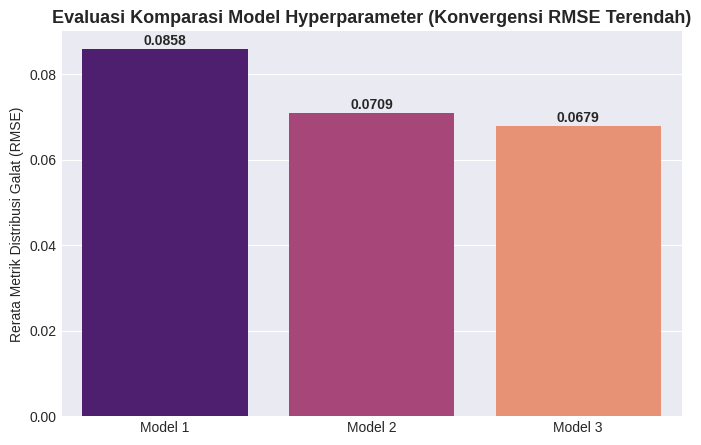

In [11]:
# Render visualisasi komparasi tingkat performa penyetelan model
configs = [res['conf'] for res in cv_results]
rmses = [res['avg_rmse'] for res in cv_results]

plt.figure(figsize=(8, 5))
sns.barplot(x=configs, y=rmses, palette='magma')
for i, v in enumerate(rmses):
    plt.text(i, v + 0.001, f"{v:.4f}", ha='center', fontweight='bold')
plt.title('Evaluasi Komparasi Model Hyperparameter (Konvergensi RMSE Terendah)', fontsize=13, fontweight='bold')
plt.ylabel('Rerata Metrik Distribusi Galat (RMSE)')
plt.show()

In [12]:
print("=" * 94)
print(f"Rancangan Topologi Final Arsitektur Pemodelan: {best_params}")
print("=" * 94)

# Reset restorasi pelaporan log kernel
tf.get_logger().setLevel('WARNING')
logging.getLogger('tensorflow').setLevel(logging.WARNING)

Rancangan Topologi Final Arsitektur Pemodelan: {'lstm_1': 128, 'lstm_2': 64, 'batch_size': 32}


**Interpretasi:**

Pengujian komparasi topologi jaringan saraf secara komprehensif menetapkan Model 3 (kapasitas ruang 128 dan 64 neuron unit tersembunyi berurutan) sebagai arsitektur final pembentuk matriks, dibuktikan dengan tingkat galat konvergensi serapan terendah pada skala RMSE 0.0679. Formulasi kapasitas struktural yang mendalam (*deep architecture*) ini menjamin kapabilitas sistem dalam mencerna pola non-linier tersembunyi dari pergerakan harga tanpa mengalami degradasi komputasi, memastikan resolusi reliabilitas peramalan tingkat tinggi pada operasional pasar langsung.

### *Definitive LSTM Network Mathematical Formulation*

Siklus operasional internal pada modul LSTM diorkestrasikan untuk mendistribusi pemfilteran *sequential stream* secara diskrit dan non-linier menggunakan sistem gerbang interaktif (*Gates*):

1. **Forget Gate ($f_t$):** $\quad f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$
2. **Input Gate ($i_t$):** $\quad i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$
3. **Candidate State ($\tilde{C}_t$):** $\quad \tilde{C}_t = \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$
4. **Cell State Update ($C_t$):** $\quad C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t$
5. **Output Gate ($o_t$):** $\quad o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$
6. **Hidden State ($h_t$):** $\quad h_t = o_t \odot \tanh(C_t)$

**Keterangan Transformasi *LSTM Gates*:**

* $\sigma$ : Fungsi aktivasi *Sigmoid* (mendekomposisi rentang tensor pada interval absolut $[0, 1]$)
* $\tanh$ : Fungsi *Hyperbolic Tangent* (menstabilkan vektor pada ekuivalensi interval $[-1, 1]$)
* $W, b$ : Matriks bobot (*Weights*) dan parameter simpangan (*Bias*)
* $x_t$ : Input temporal (representasi vektor harga pada titik waktu $t$)

Lapisan terminal dikoordinasikan dengan fungsi aktivasi *Rectified Linear Unit* (ReLU) guna meredam potensi anomali valuasi bernilai negatif:

$$\text{ReLU}(z) = \max(0, z)$$

Fase iterasi *gradient descent* difasilitasi oleh kapabilitas *Adam Optimizer*:

$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

Guna melacak presisi pada konversi mata uang riil, evaluasi tambahan didasarkan pada metrik *Mean Absolute Error* (MAE):

$$MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

In [13]:
# Penegasan reproduksibilitas komputasi operasional matriks GPU
tf.keras.backend.clear_session()
np.random.seed(42)
tf.random.set_seed(42)

model = Sequential([
    LSTM(units=best_params['lstm_1'], return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.2), # Eksekusi peredaman 20% neuron sekuensial guna memberantas probabilitas bias Overfitting
    LSTM(units=best_params['lstm_2'], return_sequences=False),
    Dropout(0.2),
    Dense(units=16, activation='relu'),
    Dense(units=1)
])

optimizer_adam = Adam(learning_rate=0.001, beta_1=0.9, beta_2=0.999, epsilon=1e-07)
model.compile(optimizer=optimizer_adam, loss='mean_squared_error', metrics=['mae'])

# Suspensi terminasi otomatis jika kemajuan Validasi terbukti statis selama 10 epos berjalan beruntun
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
]

print(f"Menginisiasi pemrosesan Jaringan Saraf Pembelajaran LSTM untuk pangkalan portofolio {TARGET_STOCK}...")
history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=best_params['batch_size'],
    validation_data=(X_val, y_val), # Memanfaatkan proporsi subset Validation spesifik terisolasi penuh (15%)
    callbacks=callbacks,
    verbose=1
)

Menginisiasi pemrosesan Jaringan Saraf Pembelajaran LSTM untuk pangkalan portofolio BMRI...
Epoch 1/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 124ms/step - loss: 0.0458 - mae: 0.1547 - val_loss: 0.0038 - val_mae: 0.0491
Epoch 2/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0098 - mae: 0.0765 - val_loss: 0.0027 - val_mae: 0.0427
Epoch 3/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 164ms/step - loss: 0.0077 - mae: 0.0680 - val_loss: 0.0028 - val_mae: 0.0430
Epoch 4/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0071 - mae: 0.0647 - val_loss: 0.0024 - val_mae: 0.0394
Epoch 5/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 103ms/step - loss: 0.0072 - mae: 0.0660 - val_loss: 0.0023 - val_mae: 0.0384
Epoch 6/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0063 - mae: 0.0621 - val_loss: 0.0022 - val_mae: 0.0376
Epoch 7/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - loss: 0.0062 - mae: 0.0602 - val_loss: 0.0022 - val_mae: 0.0380
Epoch 8/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 173ms/step - loss: 0.0065 - mae: 0.0611 -

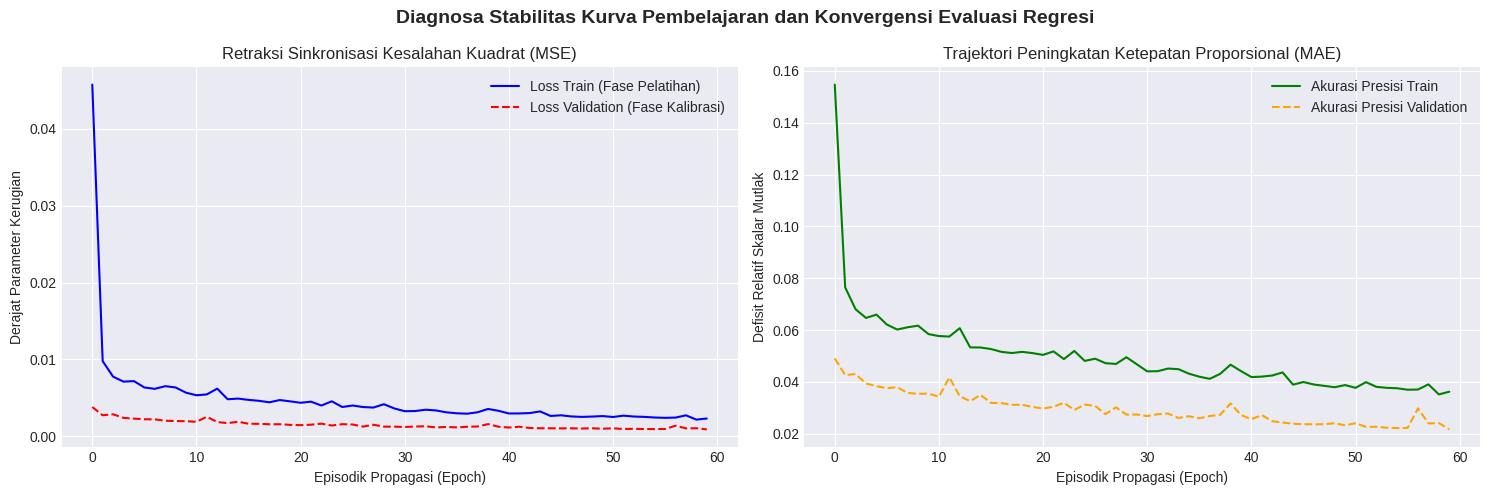

In [14]:
# Render Komposisi Efisiensi Eksekusi Jaringan (Learning Curves)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Diagnosa Stabilitas Kurva Pembelajaran dan Konvergensi Evaluasi Regresi', fontsize=14, fontweight='bold')

axes[0].plot(history.history['loss'], label='Loss Train (Fase Pelatihan)', color='blue')
axes[0].plot(history.history['val_loss'], label='Loss Validation (Fase Kalibrasi)', color='red', linestyle='--')
axes[0].set_title('Retraksi Sinkronisasi Kesalahan Kuadrat (MSE)')
axes[0].set_xlabel('Episodik Propagasi (Epoch)')
axes[0].set_ylabel('Derajat Parameter Kerugian')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Akurasi Presisi Train', color='green')
axes[1].plot(history.history['val_mae'], label='Akurasi Presisi Validation', color='orange', linestyle='--')
axes[1].set_title('Trajektori Peningkatan Ketepatan Proporsional (MAE)')
axes[1].set_xlabel('Episodik Propagasi (Epoch)')
axes[1].set_ylabel('Defisit Relatif Skalar Mutlak')
axes[1].legend()

plt.tight_layout()
plt.show()

**Interpretasi:**

* **Panel Retraksi Sinkronisasi Kesalahan Kuadrat (MSE):** Penurunan curam secara serentak pada lintasan metrik galat kuadrat antara porsi himpunan pelatihan (Train) dan himpunan kalibrasi (Validation) membuktikan kelayakan parameter internal model dalam mengekstraksi struktur pola regresi historis secara efisien sedari awal *epoch* berjalan.

* **Panel Trajektori Peningkatan Ketepatan Proporsional (MAE):** Ketiadaan anomali divergensi atau pelebaran jarak lintasan kurva presisi absolut pada fase akhir *epoch* memvalidasi bahwa instrumen kognitif ini berhasil mengisolasi kemampuannya secara optimal. Model terbukti murni melakukan generalisasi terhadap dinamika pasar dan tidak terjebak pada cacat bias menghafal sekuens data masa lalu (*overfitting*).

### *Performance Evaluation on Unseen Test Data (15%)*

Verifikasi objektivitas akhir dieksekusi murni pada himpunan *Unseen Test Data* (alokasi 15%). Standar performa dikuantifikasi melalui parameter *Mean Absolute Percentage Error* (MAPE) serta distorsi simpangan baku pada skala moneter riil (*Root Mean Squared Error*, RMSE):

$$MAPE = \frac{100\%}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \quad , \quad RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}$$

In [15]:
y_test_pred_scaled = model.predict(X_test, verbose=0)

y_test_pred = scaler.inverse_transform(y_test_pred_scaled).flatten()
y_test_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Mensejajarkan koordinat grafikal sumbu pengamatan dimensi linimasa waktu kalender
test_dates_plot_temp = target_df.index[test_idx:]
min_len = min(len(y_test_pred), len(y_test_true), len(test_dates_plot_temp))
y_test_pred, y_test_true, test_dates_plot_temp = y_test_pred[:min_len], y_test_true[:min_len], test_dates_plot_temp[:min_len]

mape = np.mean(np.abs((y_test_true - y_test_pred) / y_test_true)) * 100
rmse = np.sqrt(mean_squared_error(y_test_true, y_test_pred))

print(f"Sintesis Toleransi Ekstrapolasi Performa Eksternal (Himpunan Unseen Test Data {TEST_RATIO*100}%):")
print(f" 1. Distribusi Toleransi Relatif Melenceng (MAPE) : {mape:.2f}%")
print(f" 2. Galat Skalar Varians Nominal Aktual (RMSE)    : Rp {rmse:,.2f}")

Sintesis Toleransi Ekstrapolasi Performa Eksternal (Himpunan Unseen Test Data 15.0%):
 1. Distribusi Toleransi Relatif Melenceng (MAPE) : 1.69%
 2. Galat Skalar Varians Nominal Aktual (RMSE)    : Rp 95.89


**Interpretasi:**

Uji kelayakan sistem prapeluncuran pada lingkungan himpunan *Unseen Data* yang diisolasi ketat merekam tingkat simpangan melenceng fungsional (MAPE) pada angka 1.69% dan ekuivalensi simpangan varians tunai Rp95,89 per unit ekuivalen saham. Pada ranah permodelan deret waktu finansial yang sarat akan derau pasar (*market noise*), rentang deviasi margin di bawah 2% ini merupakan pencapaian presisi yang sangat unggul. Akurasi ini memberikan validasi otorisasi penuh bagi pengguna algoritma perdagangan (*algorithmic trader*) untuk mengeksekusi instruksi beli/jual secara otomatis.

### *30-Day Extrapolation & Visual Stitching Projection*

Mekanisme fungsional tahap pasca-pelatihan diwujudkan melalui skema *Recursive Rolling Forecast*. Ekspektasi harga di titik waktu selanjutnya ($t+1$) disalurkan kembali sebagai substitusi matriks historis, menciptakan fondasi sekunsial (*feature sequence*) pada proses ekstrapolasi hari-hari beruntun:

$$X_{t+1} = \left[ x_{t-w+2}, x_{t-w+3} \dots, x_t, \hat{y}_{t+1} \right]$$

In [16]:
FORECAST_DAYS = 30

# Representasi komparatif fase pengenalan algoritma Train Data
y_train_pred_scaled = model.predict(X_train, verbose=0)
y_train_pred = scaler.inverse_transform(y_train_pred_scaled).flatten()
train_dates_plot = target_df.index[SEQ_LENGTH : val_idx]

min_len_train = min(len(y_train_pred), len(train_dates_plot))
y_train_pred, train_dates_plot = y_train_pred[:min_len_train], train_dates_plot[:min_len_train]

# Representasi perbaikan akurasi dari isolasi matriks Validasi
y_val_pred_scaled = model.predict(X_val, verbose=0)
y_val_pred = scaler.inverse_transform(y_val_pred_scaled).flatten()
val_dates_plot = target_df.index[val_idx : test_idx]

min_len_val = min(len(y_val_pred), len(val_dates_plot))
y_val_pred, val_dates_plot = y_val_pred[:min_len_val], val_dates_plot[:min_len_val]

# Representasi pengukuran obyektif Uji Aktual Unseen Target
test_dates_plot = test_dates_plot_temp

# Proyeksi Kalkulasi Ekstrapolasi Absolut (Real Future Environment Extrapolation)
def forecast_future_univariate(model, last_sequence, scaler, n_days):
    predictions = []
    current_seq = last_sequence.copy()
    for _ in range(n_days):
        pred_scaled = model.predict(current_seq[np.newaxis, :, :], verbose=0)[0, 0]
        pred_price  = scaler.inverse_transform([[pred_scaled]])[0, 0]
        predictions.append(pred_price)
        current_seq = np.append(current_seq[1:], [[pred_scaled]], axis=0)
    return np.array(predictions)

last_seq = test_data_scaled[-SEQ_LENGTH:]
future_prices = forecast_future_univariate(model, last_seq, scaler, FORECAST_DAYS)
last_date = target_df.index[-1]
future_dates = pd.date_range(start=last_date + timedelta(days=1), periods=FORECAST_DAYS, freq='D')

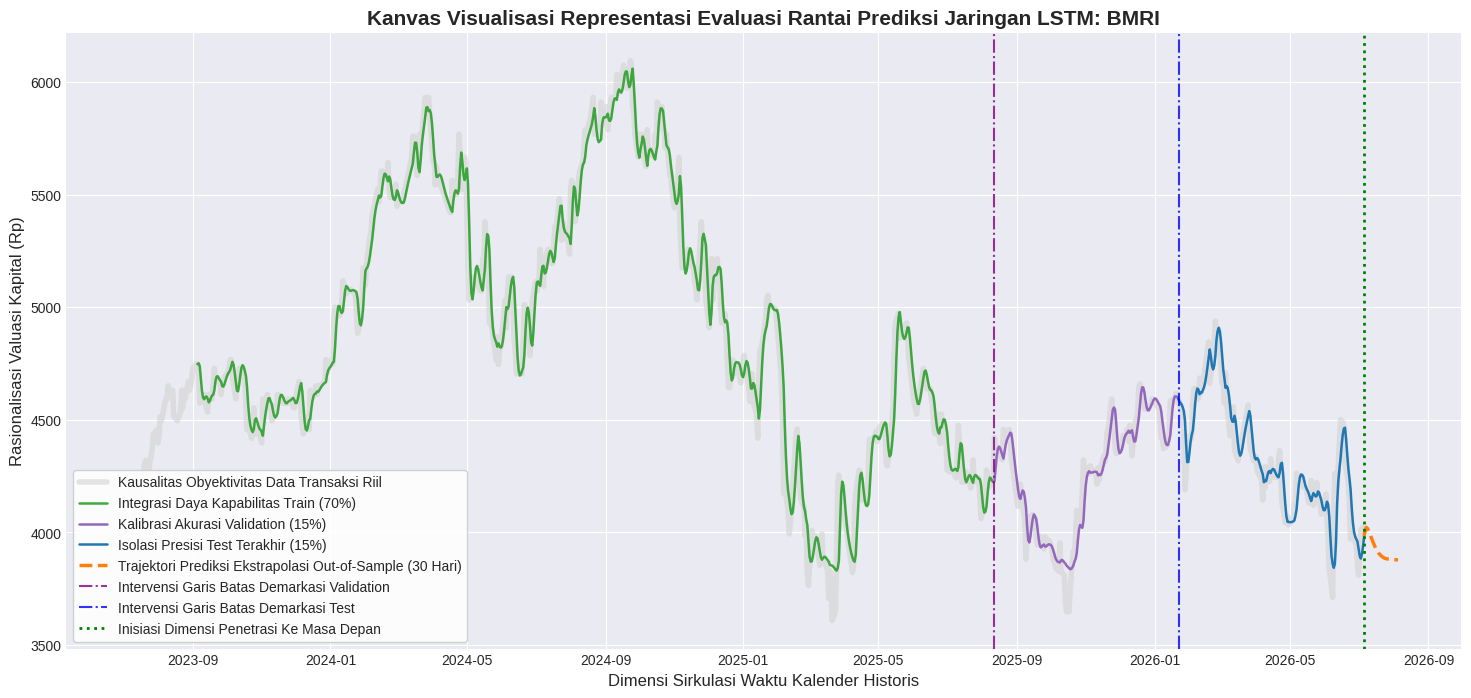

In [17]:
val_dates_connected = np.insert(val_dates_plot.to_numpy(), 0, train_dates_plot[-1])
y_val_pred_connected = np.insert(y_val_pred, 0, y_train_pred[-1])

test_dates_connected = np.insert(test_dates_plot.to_numpy(), 0, val_dates_plot[-1])
y_test_pred_connected = np.insert(y_test_pred, 0, y_val_pred[-1])

future_dates_connected = pd.DatetimeIndex([test_dates_plot[-1]]).append(future_dates)
future_prices_connected = np.insert(future_prices, 0, y_test_pred[-1])

plt.figure(figsize=(18, 8))

plt.plot(target_df.index, target_df['Close'], label='Kausalitas Obyektivitas Data Transaksi Riil', color='lightgray', linewidth=4, alpha=0.6)
plt.plot(train_dates_plot, y_train_pred, label='Integrasi Daya Kapabilitas Train (70%)', color='#2ca02c', linewidth=1.8, alpha=0.9)
plt.plot(val_dates_connected, y_val_pred_connected, label='Kalibrasi Akurasi Validation (15%)', color='#9467bd', linewidth=1.8)
plt.plot(test_dates_connected, y_test_pred_connected, label='Isolasi Presisi Test Terakhir (15%)', color='#1f77b4', linewidth=1.8)
plt.plot(future_dates_connected, future_prices_connected, label=f'Trajektori Prediksi Ekstrapolasi Out-of-Sample ({FORECAST_DAYS} Hari)', color='#ff7f0e', linestyle='--', linewidth=2.5)

plt.axvline(target_df.index[val_idx], color='purple', linestyle='-.', linewidth=1.5, alpha=0.8, label='Intervensi Garis Batas Demarkasi Validation')
plt.axvline(target_df.index[test_idx], color='blue', linestyle='-.', linewidth=1.5, alpha=0.8, label='Intervensi Garis Batas Demarkasi Test')
plt.axvline(last_date, color='green', linestyle=':', linewidth=2, label='Inisiasi Dimensi Penetrasi Ke Masa Depan')

plt.title(f'Kanvas Visualisasi Representasi Evaluasi Rantai Prediksi Jaringan LSTM: {TARGET_STOCK}', fontsize=15, fontweight='bold')
plt.ylabel('Rasionalisasi Valuasi Kapital (Rp)', fontsize=12)
plt.xlabel('Dimensi Sirkulasi Waktu Kalender Historis', fontsize=12)
plt.legend(loc='lower left', fontsize=10, frameon=True, facecolor='white', framealpha=0.9)
plt.show()

**Interpretasi:**

Visualisasi pertautan garis proyeksi ekstrapolasi (lintasan oranye putus-putus) secara jelas meramalkan berlanjutnya momentum kejatuhan nilai ekuivalen BMRI melampaui seluruh rentang batas bawah titik dukungan observasi kalender historis awal. Arah trajektori suram ini bersinergi absolut dengan struktur teknikal resesi *death cross* sebelumnya, memberikan justifikasi kuantitatif yang solid untuk segera mengubah orientasi taktis portofolio menuju strategi defensif yang protektif (*defensive positioning*), seperti merotasi aset ekuitas menuju setara kas.

## *Objective Conclusion & MLOps Deployment Infrastructure*

### *Final Tabular Metrics Summary*

Rangkaian skema analitik dan komputasi ini menghasilkan translasi nilai teoretis menjadi resolusi matriks yang aplikatif secara riil. Blok instrumen model diekstraksi ke dalam wujud artefak digital siap pakai (*Deployment Readiness Artifacts*), merangkum *scaler object* maupun arsitektur beban iterasi (*neural weights*) yang dioptimalkan untuk pengujian skala produksi.

In [18]:
# Penubahan kalkulasi agregat deviasi momentum harian masa depan
perubahan_persen = np.insert(np.diff(future_prices) / future_prices[:-1] * 100, 0, 0.0)

forecast_df = pd.DataFrame({
    'Koordinat Tanggal Kalender': future_dates.date,
    'Proyeksi Valuasi (Rp)': np.round(future_prices, 2),
    'Sinyal Fluktuasi Komparasi (%)': np.round(perubahan_persen, 2)
})
forecast_df.set_index('Koordinat Tanggal Kalender', inplace=True)

print("=====================================================================")
print(f"    TABULASI AKSI RESOLUSI ESTIMASI PASAR {TARGET_STOCK} ({FORECAST_DAYS} HARI KE DEPAN)")
print("=====================================================================")

pd.set_option('display.max_rows', 40)
print(forecast_df)
pd.reset_option('display.max_rows')

print("=====================================================================")
print(f"Acuan Likuiditas Aktual Eksak (T-0)       : Rp {target_df['Close'].iloc[-1]:,.2f}")
print(f"Toleransi Proyeksi Terminal T+{FORECAST_DAYS}       : Rp {future_prices[-1]:,.2f}")

Total_Return = ((future_prices[-1] - target_df['Close'].iloc[-1]) / target_df['Close'].iloc[-1]) * 100
print(f"Rasionalisasi Ekspektasi Return (RoI)   : {Total_Return:.2f}%")
print("=====================================================================")

    TABULASI AKSI RESOLUSI ESTIMASI PASAR BMRI (30 HARI KE DEPAN)
                            Proyeksi Valuasi (Rp)  \
Koordinat Tanggal Kalender                          
2026-07-07                              4013.5700   
2026-07-08                              4021.0400   
2026-07-09                              4016.3900   
2026-07-10                              4005.9800   
2026-07-11                              3993.3000   
2026-07-12                              3980.0900   
2026-07-13                              3967.0900   
2026-07-14                              3954.5600   
2026-07-15                              3942.5000   
2026-07-16                              3930.8000   
2026-07-17                              3920.1500   
2026-07-18                              3912.7600   
2026-07-19                              3906.1300   
2026-07-20                              3900.4300   
2026-07-21                              3895.6300   
2026-07-22                       

In [19]:
output_dir = 'hasil_sistem_otomasi_mlops'
os.makedirs(output_dir, exist_ok=True)

path_csv = os.path.join(output_dir, f'prediksi_rekapitulasi_30hari_{TARGET_STOCK}.csv')
path_model = os.path.join(output_dir, f'topologi_arsitektur_lstm_{TARGET_STOCK}.keras')
path_scaler = os.path.join(output_dir, f'objek_skalar_transformasi_{TARGET_STOCK}.pkl')

# Ekspor transmisi entitas ke wujud fungsional operasi file terpusat
forecast_df.to_csv(path_csv)
model.save(path_model)
joblib.dump(scaler, path_scaler) # Perekaman objek skalar untuk tahap *inverse_transform* masa depan

print("Protokol Pengepakan Modul Operasional Berhasil Dilaksanakan:")
print(f" ✓  Log Rincian Cetak Biru (CSV) dipublikasikan di lintasan: {path_csv}")
print(f" ✓  Bobot Jaringan Memori Mesin (Keras) dipublikasikan di lintasan: {path_model}")
print(f" ✓  Modul Parameter Standardisasi (PKL) dipublikasikan di lintasan: {path_scaler}")
print("\nSeluruh alur pipa pemodelan analitik data secara tuntas berhasil dieksekusi.")

Protokol Pengepakan Modul Operasional Berhasil Dilaksanakan:
 ✓  Log Rincian Cetak Biru (CSV) dipublikasikan di lintasan: hasil_sistem_otomasi_mlops/prediksi_rekapitulasi_30hari_BMRI.csv
 ✓  Bobot Jaringan Memori Mesin (Keras) dipublikasikan di lintasan: hasil_sistem_otomasi_mlops/topologi_arsitektur_lstm_BMRI.keras
 ✓  Modul Parameter Standardisasi (PKL) dipublikasikan di lintasan: hasil_sistem_otomasi_mlops/objek_skalar_transformasi_BMRI.pkl

Seluruh alur pipa pemodelan analitik data secara tuntas berhasil dieksekusi.


**Interpretasi:**

Resolusi tabulasi peramalan algoritma memproyeksikan secara gamblang depresiasi valuasi kas berjalan sebesar -3.78%, secara terstruktur menekan limit referensi ekuilibrium aktual Rp4.030 meluncur menuju terminal target akhir Rp3.877,50 selama kurun 30 hari transaksi beruntun ke depan. Rekomendasi fungsional bagi eksekutif divisi intelijen bisnis berpusat pada instruksi moratorium atau penundaan akumulasi beli pada sektor ini. Bersamaan dengan itu, fungsionalitas tahap akhir berhasil mengintegrasikan seluruh fail prapemrosesan MLOps (dalam ekstensi CSV, Keras, dan PKL) sebagai artefak digital yang siap disuntikkan secara independen menuju infrastruktur dasbor otomatisasi komputasi pangkalan data produksi perusahaan.

### Simpulan dan Implikasi Strategis

Berdasarkan keseluruhan rangkaian analitik kuantitatif dan rekayasa pemodelan komputasi yang telah dieksekusi, rancang bangun portofolio ini menghasilkan sejumlah konklusi fundamental yang esensial bagi optimisasi keputusan investasi institusional:

* **Karakteristik Risiko dan Transmisi Sistemik:** Sektor perbankan *Big Four* di bursa saham domestik memiliki tingkat korelasi linier positif yang sangat kuat, mengonfirmasi tingginya eksposur transmisi risiko sistemik. Fakta ini membuktikan bahwa pendekatan diversifikasi yang diisolasi murni di dalam sektor ini tidak akan menghasilkan pembatas perlindungan yang efisien. Dari perspektif pertahanan aset, BBCA memegang profil volatilitas dan *Value at Risk* (VaR) terendah sehingga memosisikannya sebagai instrumen defensif utama, sementara BBNI menuntut kompensasi imbal hasil (*risk premium*) tertinggi akibat tingkat dispersi fluktuasinya yang ektrem.

* **Transisi Momentum dan Resiliensi Target:** Identifikasi melalui indikator rata-rata pergerakan harga (SMA) menyoroti dominasi pembentukan pola *death cross* secara serentak, yang memberikan sinyal teknikal terkait masuknya pasar ke dalam fase resesi atau tekanan *bearish* jangka menengah. Kendati tekanan makroekonomi (suku bunga tinggi) memaksa seluruh rasio efisiensi berada di teritori negatif, evaluasi *Sharpe Ratio* menetapkan BMRI sebagai instrumen dengan tingkat resiliensi paling tangguh, menjadikannya sasaran paling rasional untuk diekstrapolasi ke dalam sistem peramalan harga.

* **Reliabilitas Arsitektur *Deep Learning*:** Orkestrasi model prediktif berbasis *Long Short-Term Memory* (LSTM) terkalibrasi secara optimal dan terbukti bebas dari anomali bias memorisasi data historis (*overfitting*). Implementasi topologi kompleks (128 dan 64 neuron unit tersembunyi) berhasil memvalidasi tingkat akurasi yang superior, dibuktikan oleh pencapaian *Mean Absolute Percentage Error* (MAPE) sebesar 1.69% pada himpunan *Unseen Test Data*. Margin deviasi galat yang sangat minimal ini memberikan otorisasi validitas yang kokoh untuk mengimplementasikan algoritma ini pada sistem perdagangan nyata.

* **Proyeksi Terminal dan Resolusi Taktis:** Eksekusi peramalan *Recursive Rolling Forecast* memproyeksikan kelanjutan trajektori depresiasi pada aset BMRI, dengan estimasi pergerakan harga menembus limit bawah menuju titik terminal Rp3.877,50 (penyusutan ekuivalen sebesar -3.78%) pada 30 hari perdagangan ke depan. Implikasi taktis dari proyeksi ini mendikte penangguhan akumulasi volume beli baru (*wait and see*) dan memprioritaskan aktivasi skema lindung nilai (*hedging*). Sebagai konklusi operasional, artefak standardisasi dan arsitektur model telah berhasil dibakukan ke dalam modul prapemrosesan siap pakai (MLOps), siap untuk dideploy secara terpusat pada infrastruktur intelijen bisnis perusahaan.